In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sympy import symbols, groebner ,solve, Rational, simplify
print("x")

x


In [2]:
# Restricciones (1-(p1+p2+p3)=0), E y V
p1 = 0.3
m1 = 0.1
m2 = 0.05
m3 = 0.2
v1 = 0.2
v2 = 0.1
v3 = 0.3
cv12 = 0.05 
cv13 = 0.1
cv23 =  0.2

p1, p2, E, V = symbols('p1 p2 E V')

p3 = 1 - p1 - p2

E_resta = m1*p1 + m2*p2 + m3*p3
pol2 = E - E_resta

V_resta = (
    v1*p1**2 + v2*p2**2 + v3*p3**2 +
    2*cv12*p1*p2 +
    2*cv13*p1*p3 +
    2*cv23*p2*p3
)

pol3 = V - V_resta

In [4]:
G = groebner([pol2, pol3], p1, p2, E, V, order='lex')

In [5]:
list(G)

[10.0*E + 1.0*p1 + 1.5*p2 - 2.0,
 57.1428571428571*E**2 + 15.2380952380952*E*p2 - 15.2380952380952*E - 1.9047619047619*V + 1.0*p2**2 - 2.28571428571429*p2 + 1.33333333333333]

In [6]:
E_reducido = -(1.0*p1 + 1.5*p2 - 2.0)/10

In [10]:
eq1 = 10.0*E + 1.0*p1 + 1.5*p2 - 2.0
eq2 = 57.1428571428571*E**2 + 15.2380952380952*E*p2 - 15.2380952380952*E - 1.9047619047619*V + 1.0*p2**2 - 2.28571428571429*p2 + 1.33333333333333

p1_expr = solve(eq1, p1)[0]
eq2_sub = simplify(eq2)

# 3) resolver para p2
sol_p2 = solve(eq2_sub, p2)

print("Soluciones para p2:")
print(sol_p2)

Soluciones para p2:
[-7.61904761904762*E - 0.0952380952380952*sqrt(100.0*E**2 - 240.0*E + 210.0*V - 3.0) + 1.14285714285714, -7.61904761904762*E + 0.0952380952380952*sqrt(100.0*E**2 - 240.0*E + 210.0*V - 3.0) + 1.14285714285714]


Vemos que nos da 2 ecuaciones, una de ella seguramente no sea valida.
Ahora hay 2 caminos, fijar E o fijar V, vamos a ver las 2 posibilidades<br>
Si fijamos E, entonces nos queda un polinomio en funcion de V, el objetivo sera minimizar esta V, <br>
Al reves para V, si dijamos V nuestro objetivo es maximizar E<br>

In [49]:
#Por ejemplo, fijemos E = 3.4 (inflacion de españa, tiene que vencer la inflacion) + 5%
E, V = sp.symbols('E V', real=True)

E_valor = 0

p1 = -7.61904761904762*E - 0.0952380952380952*sp.sqrt(
    100.0*E**2 - 240.0*E + 210.0*V - 3.0
) + 1.14285714285714

p2 = -7.61904761904762*E + 0.0952380952380952*sp.sqrt(
    100.0*E**2 - 240.0*E + 210.0*V - 3.0
) + 1.142

In [50]:
p1_E = p1.subs(E, E_valor)
p2_E = p2.subs(E, E_valor)
print(p1_E)
print(p2_E)

-0.0952380952380952*sqrt(210.0*V - 47.0) - 0.380952380952384
0.0952380952380952*sqrt(210.0*V - 47.0) - 0.381809523809524


In [46]:
df = sp.diff(p1_E, V)
print(df)

-10.0/sqrt(210.0*V - 47.0)


<lambdifygenerated-9>:2: RuntimeWarning: invalid value encountered in sqrt
  return -10.0/sqrt(210.0*V - 22.4544)


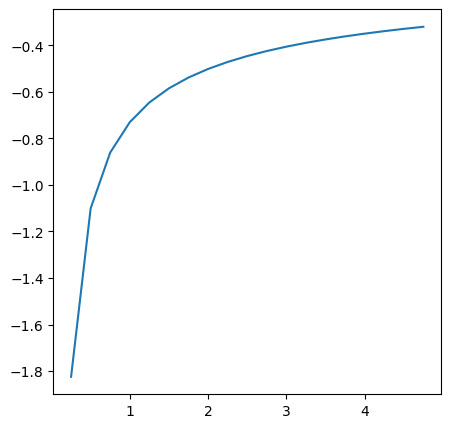

In [51]:
f = -10.0/sp.sqrt(210.0*V - 22.4544)
valores = np.arange(0,5, 0.25)
f_np = sp.lambdify(V, f, "numpy")
plt.figure(figsize=(5,5))
plt.plot(valores,f_np(valores))
plt.show()

<lambdifygenerated-12>:2: RuntimeWarning: invalid value encountered in sqrt
  return 0.0952380952380952*sqrt(210.0*V - 22.4544) + 0.502


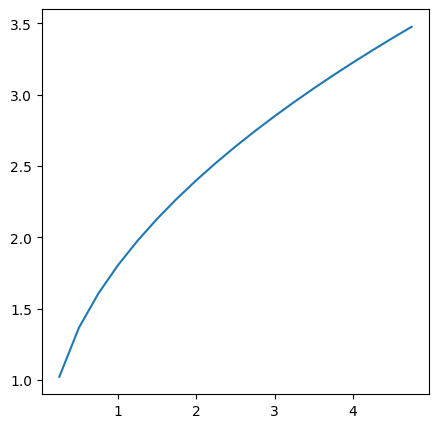

1.0240368272254283


In [54]:
f2 = 0.0952380952380952*sp.sqrt(210.0*V - 22.4544) + 0.502
f_np2 = sp.lambdify(V, f2, "numpy")
plt.figure(figsize=(5,5))
plt.plot(valores,f_np2(valores))
plt.show()
print(f_np2(valores[1]))